In [1]:
# Customer Analytics Exploratory Data Analysis

""" This dataset contains customer demographic and purchasing behavior information.
Each row represents a single customer profile including age, income,
shopping frequency, device usage, and spending behavior.

The goal of this analysis is to understand customer characteristics,
identify purchasing patterns and uncover relationships between
income, spending score, and online activity."""

' This dataset contains customer demographic and purchasing behavior information.\nEach row represents a single customer profile including age, income,\nshopping frequency, device usage, and spending behavior.\n\nThe goal of this analysis is to understand customer characteristics,\nidentify purchasing patterns and uncover relationships between\nincome, spending score, and online activity.'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("customer_analytics.csv")
df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


In [5]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [6]:
### Cleaning Decisions
""" 1. Education column contains few missing values.
   * Filled using most frequent category (mode).
2. AnnualIncome has missing values.
   * Filled using median income to avoid influence of outliers.
3. No columns were dropped because missing percentage was small."""

' 1. Education column contains few missing values.\n   * Filled using most frequent category (mode).\n2. AnnualIncome has missing values.\n   * Filled using median income to avoid influence of outliers.\n3. No columns were dropped because missing percentage was small.'

In [7]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].median())

In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

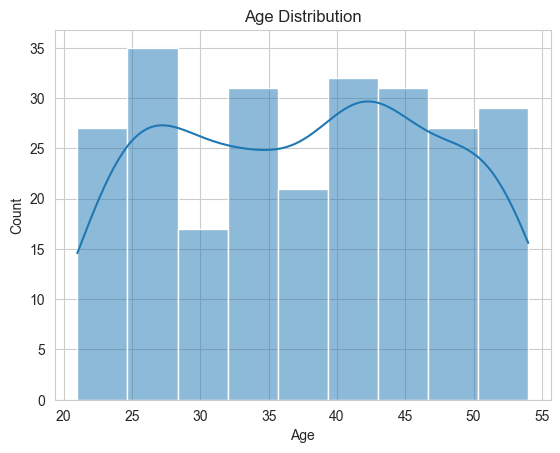

In [9]:
plt.figure()
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

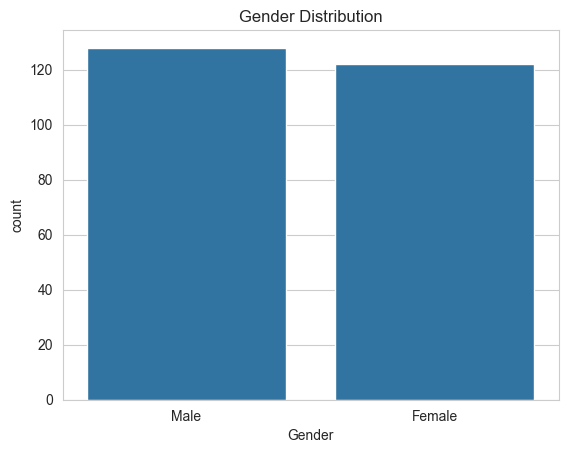

In [10]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

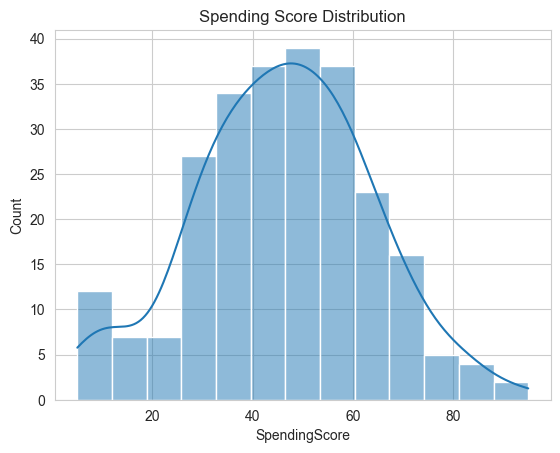

In [11]:
sns.histplot(df['SpendingScore'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

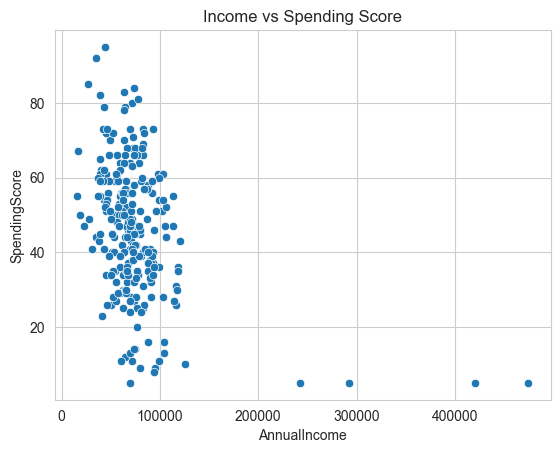

In [12]:
sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df)
plt.title("Income vs Spending Score")
plt.show()

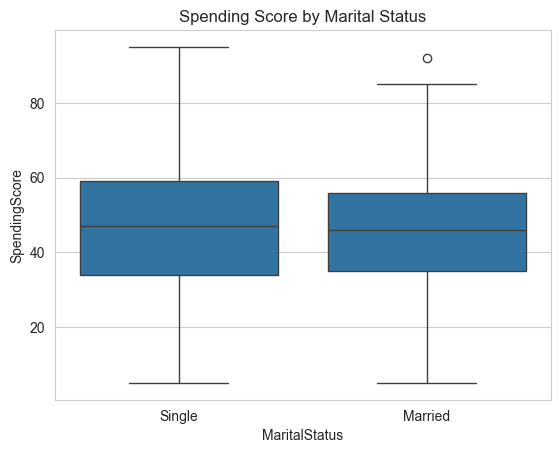

In [13]:
sns.boxplot(x='MaritalStatus', y='SpendingScore', data=df)
plt.title("Spending Score by Marital Status")
plt.show()

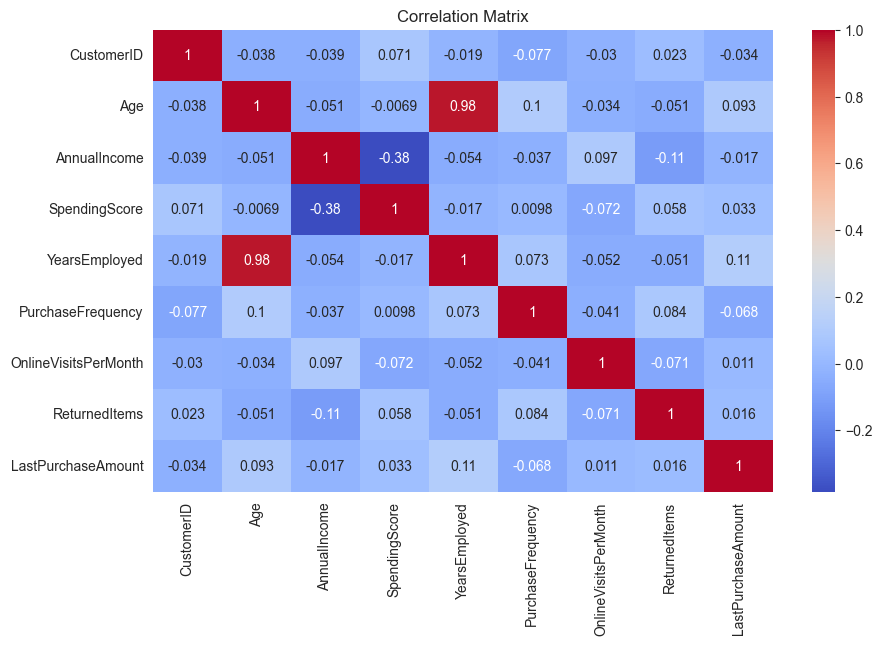

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [15]:
# Executive Summary

### Insight 1
"""Middle-aged customers dominate purchasing activity.

### Insight 2
Income level alone does not strongly determine spending score,
suggesting psychological or lifestyle influences.

### Insight 3
Online visits and purchase frequency show positive association,
indicating digital engagement drives sales."""

'Middle-aged customers dominate purchasing activity.\n\n### Insight 2\nIncome level alone does not strongly determine spending score,\nsuggesting psychological or lifestyle influences.\n\n### Insight 3\nOnline visits and purchase frequency show positive association,\nindicating digital engagement drives sales.'